#lab3 
#Mohammed Moayed AlQurini - 2240007325 - 7MA2
# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

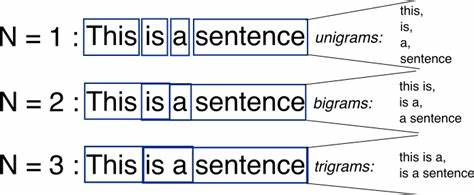

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** an n-gram consisting of a single item from a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$ count of (A) \div corpus length $

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [ ]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('toeses', 1),
 ('are', 1),
 ('roses', 1),
 ('his', 1),
 ('but', 1),
 ('erroneously', 1),
 ('supposes', 2),
 ('moses', 2)]

In [ ]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(string)
    probab.append(pro)

print('the probabilities are: ',probab)

the probabilities are:  [0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.030303030303030304]


In [ ]:
probabilities = []
for i,j in zip(unique_string, probab):
    probabilities.append((i,j))
probabilities

[('toeses', 0.015151515151515152),
 ('are', 0.015151515151515152),
 ('roses', 0.015151515151515152),
 ('his', 0.015151515151515152),
 ('but', 0.015151515151515152),
 ('erroneously', 0.015151515151515152),
 ('supposes', 0.030303030303030304),
 ('moses', 0.030303030303030304)]

## Bigram

**Bigram** an n-gram consisting of two items from a sequence
- Two words that are used together to mean something specific

$ countof(A \ then \ B) \div countof(A) $

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nl.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [ ]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nl.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in 1.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

n-1 padding is added.



In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [ ]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.

- Build the vocabulary: to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create and Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.


**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [ ]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [ ]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model
print(lm.vocab)
print(len(lm.vocab))

<Vocabulary with cutoff=1 unk_label='<UNK>' and 11 items>
11


In [ ]:
lm.vocab.lookup(['moses','supposes'])

('moses', 'supposes')

In [ ]:
lm.vocab.lookup(['moses'])

('moses',)

### counts for unigrams and bigrams

In [ ]:
print(lm.counts['moses'])
# a then b
print(lm.counts[['moses']]['supposes'])

2
2


In [ ]:
print(lm.score('moses')) #Calculate Bigram Probabilities

0.16666666666666666


Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [ ]:
# b then a
lm.score("supposes", ["moses"])

1.0

### Evaluating n_grams models using preplexity

**Preplexity** is the probability of the test set normalized by the number of words

In [ ]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test))

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions




3. build MLE model with n-gram
4. evaluate the model

before we start we need to install library to handle the emojis in tweets
> pip install emoji

---
# Task Solution (Lab3 - Part 1): Generating Tweets using N-grams

**Requirements covered in this section:**
1. Load the dataset (Random Tweets from Pakistan).
2. Pre-process the data: remove mentions, hashtags, RT, websites, extra symbols, extra spaces.
3. Build an MLE Bigram model and generate tweets.
4. Evaluate the model (perplexity).
5. Calculate: unigram count, bigram count, trigram count, three conditional probabilities, and perplexity.

Dataset file (place next to this notebook): `Random_Tweets_from_Pakistan-_Cleaned-_Anonymous.csv`

### Step 0: Install/import required libraries

In [1]:
# pip install emoji   (uncomment the line below if 'emoji' is not installed yet)
# !pip install emoji

import pandas as pd
import re
import random
import emoji
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.lm import MLE
from nltk.util import bigrams

### Step 1: Load the data

In [2]:
df_tweets = pd.read_csv(
    'Random_Tweets_from_Pakistan-_Cleaned-_Anonymous.csv',
    encoding='utf-8',
    encoding_errors='replace',   # a handful of bytes in the file are corrupted; replace instead of crashing
    low_memory=False
)

df_tweets = df_tweets.dropna(subset=['full_text']).reset_index(drop=True)
print("Rows loaded:", df_tweets.shape[0])
df_tweets[['full_text']].head()

Rows loaded: 202151


,full_text
0,تیرا لیڈر میرا لیڈر نواز شریف نواز شریف❤️ کیا...
1,"Happy birthday to my brother n boss , May you ..."
2,❤️❤️
3,`suspicious °jikook au jimin'in yaşadığı kasab...
4,Speaking of @SpiderMan... 😂 https://t.co/uGJ...


### Step 2: Pre-process the data

Cleaning steps applied (as required):
- Remove mentions (`@username`)
- Remove hashtags (`#tag`)
- Remove the `RT` retweet marker
- Remove URLs/websites
- Remove emojis (using the `emoji` library)
- Remove extra symbols/punctuation (keep letters only)
- Lowercase everything and collapse extra spaces

In [3]:
def clean_tweet_series(series):
    s = series.astype(str)
    s = s.str.replace(r'http\S+|www\.\S+', '', regex=True)   # websites
    s = s.str.replace(r'@\w+', '', regex=True)                 # mentions
    s = s.str.replace(r'#\w+', '', regex=True)                 # hashtags
    s = s.str.replace(r'\bRT\b', '', regex=True)               # RT marker
    s = s.apply(lambda t: emoji.replace_emoji(t, replace=''))  # emojis
    s = s.str.replace(r'[^A-Za-z\s]', ' ', regex=True)         # extra symbols/punctuation/numbers
    s = s.str.lower()
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()     # extra spaces
    return s

df_tweets['clean_text'] = clean_tweet_series(df_tweets['full_text'])

# Drop tweets that became empty after cleaning (e.g. tweets that were only a URL or non-English script)
df_tweets = df_tweets[df_tweets['clean_text'].str.len() > 0].reset_index(drop=True)

print("Tweets remaining after cleaning:", df_tweets.shape[0])
df_tweets[['full_text', 'clean_text']].head(10)

Tweets remaining after cleaning: 143228


,full_text,clean_text
0,"Happy birthday to my brother n boss , May you ...",happy birthday to my brother n boss may you ha...
1,`suspicious °jikook au jimin'in yaşadığı kasab...,suspicious jikook au jimin in ya ad kasabada a...
2,Speaking of @SpiderMan... 😂 https://t.co/uGJ...,speaking of
3,"Alexa, skip to 2021",alexa skip to
4,Jb tm moon lover ho gy to sooraj to tappy ga na 😒,jb tm moon lover ho gy to sooraj to tappy ga na
5,Alexa skip to 2022 now,alexa skip to now
6,"But this was one of my first shoots, about 6 y...",but this was one of my first shoots about year...
7,Trying phoneix in 140 ping 🔥 https://t.co/CpjY...,trying phoneix in ping
8,Cant sleep 🥵🥱 So why not . https://t.co/WjmRMB...,cant sleep so why not
9,@n1ffyyy Ayy gonna miss you too 🥺,ayy gonna miss you too


In [4]:
# Tokenize each cleaned tweet into a list of words -> this is our "corpus" of sentences
sentences = [t.split() for t in df_tweets['clean_text'] if len(t.split()) > 0]
print("Number of tokenized tweets:", len(sentences))
print("Example tokenized tweet:", sentences[0])

# Train / held-out split, used later to evaluate perplexity on unseen data
random.seed(42)
shuffled = sentences.copy()
random.shuffle(shuffled)
split_idx = int(len(shuffled) * 0.9)
train_sents, test_sents = shuffled[:split_idx], shuffled[split_idx:]
print(f"Train tweets: {len(train_sents)} | Held-out test tweets: {len(test_sents)}")

Number of tokenized tweets: 143228
Example tokenized tweet: ['happy', 'birthday', 'to', 'my', 'brother', 'n', 'boss', 'may', 'you', 'have', 'many', 'many', 'more', 'you', 'are', 'gem']
Train tweets: 128905 | Held-out test tweets: 14323


### Step 3: Build an MLE Bigram model

In [5]:
train_data, vocab = padded_everygram_pipeline(2, train_sents)

bigram_lm = MLE(2)
bigram_lm.fit(train_data, vocab)

print("Bigram model trained.")
print("Vocabulary size:", len(bigram_lm.vocab))

Bigram model trained.
Vocabulary size: 72489


### Step 4: Generate tweets with the Bigram model

In [6]:
def generate_tweet(model, num_words=15, seed=None):
    words = []
    for token in model.generate(num_words, random_seed=seed):
        if token == '<s>':
            continue
        if token == '</s>':
            break
        words.append(token)
    return ' '.join(words)

print("Generated tweets:\n")
for i in range(5):
    print(f"{i+1}. {generate_tweet(bigram_lm, num_words=15, seed=i)}")

Generated tweets:



1. the saath of hattin guy in the first line of thousands of humanity probe pakistani
2. address to several extensions was how sweet of biotechnology biotech says it secondly are near


3. were treated as a standing up our education minister narendra modi brought in late sri
4. broadcast journalist and out of and a state from faisalabad without firing riaz khokhar jun


5. brandend kruis


### Step 5: Evaluate the model (Perplexity)

We evaluate on two samples for comparison:
- A sample of **unseen (held-out)** tweets — realistic evaluation.
- A sample of tweets the model was **trained on** — for contrast.

Because this is a plain **MLE model with no smoothing**, any bigram in the test set that the model
never saw during training gets probability **0**, which makes the perplexity **infinite**. This is
expected, well-known behavior of unsmoothed MLE models (see Jurafsky & Martin, Ch.3) — it is *not*
a bug in the code.

In [7]:
test_sample = test_sents[:200]
test_bigrams = [bg for s in test_sample for bg in list(bigrams(pad_both_ends(s, n=2)))]
perplexity_held_out = bigram_lm.perplexity(test_bigrams)
print("Perplexity on held-out (unseen) tweets:", perplexity_held_out)

train_sample = train_sents[:200]
train_bigrams = [bg for s in train_sample for bg in list(bigrams(pad_both_ends(s, n=2)))]
perplexity_seen = bigram_lm.perplexity(train_bigrams)
print("Perplexity on a sample of tweets the model was trained on:", perplexity_seen)

Perplexity on held-out (unseen) tweets: inf
Perplexity on a sample of tweets the model was trained on: 66.82760496324558


### Step 6: Required counts and probabilities

The count/probability list also asks for **trigram**-level statistics
(`count of trigram 'a/pakistan is'`, `P('a' | 'pakistan is')`). A **Bigram**-order model
structurally cannot answer a 2-word-context query correctly — it silently returns `0` for anything
beyond its order, which would be a wrong answer, not just a missing one. So, purely to answer
those two specific trigram items correctly, we fit a second **Trigram** MLE model on the exact same
training sentences. The tweet generation and perplexity evaluation above still use the Bigram model,
as required.

In [8]:
train_data3, vocab3 = padded_everygram_pipeline(3, train_sents)

trigram_lm = MLE(3)
trigram_lm.fit(train_data3, vocab3)

print("Trigram model trained (used only for the trigram-level stats below).")

Trigram model trained (used only for the trigram-level stats below).


In [9]:
# --- Counts ---
unigram_count_pakistan = bigram_lm.counts['pakistan']
bigram_count_is_pakistan = bigram_lm.counts[['pakistan']]['is']          # count of "pakistan is"
trigram_count_a_pakistan_is = trigram_lm.counts[['pakistan', 'is']]['a'] # count of "pakistan is a"

print("Count of unigram 'pakistan'        :", unigram_count_pakistan)
print("Count of bigram  'is' | 'pakistan' :", bigram_count_is_pakistan)
print("Count of trigram 'a' | 'pakistan is':", trigram_count_a_pakistan_is)

Count of unigram 'pakistan'        : 12627
Count of bigram  'is' | 'pakistan' : 616
Count of trigram 'a' | 'pakistan is': 63


In [10]:
# --- Probabilities ---
p_pakistan_given_start = bigram_lm.score('pakistan', ['<s>'])
p_is_given_pakistan     = bigram_lm.score('is', ['pakistan'])
p_a_given_pakistan_is   = trigram_lm.score('a', ['pakistan', 'is'])

print("P('pakistan' | <s>)        :", p_pakistan_given_start)
print("P('is' | 'pakistan')       :", p_is_given_pakistan)
print("P('a' | 'pakistan is')     :", p_a_given_pakistan_is)

P('pakistan' | <s>)        : 0.009759124936969087
P('is' | 'pakistan')       : 0.04878435099390196
P('a' | 'pakistan is')     : 0.10227272727272728


### Summary of Results

(Numbers below are the actual output from running the cells above, on the 90% train split.)

| Metric | Value |
|---|---|
| Count of unigram `pakistan` | 12,627 |
| Count of bigram `pakistan -> is` | 616 |
| Count of trigram `pakistan is -> a` | 63 |
| P(`pakistan` given `<s>`) | ~ 0.00976 |
| P(`is` given `pakistan`) | ~ 0.04878 |
| P(`a` given `pakistan is`) | ~ 0.10227 |
| Perplexity on held-out (unseen) tweets | `inf` (unseen bigrams -> zero probability, expected for unsmoothed MLE) |
| Perplexity on a seen training sample | ~ 66.83 |

*(These numbers depend on the 90/10 random train/test split, so a different `random.seed()` value
will shift them slightly -- the held-out perplexity will still be `inf` regardless of the seed.)*

---
# Task Solution (Lab3 - Part 2, Task#1): Text Analysis and NLP (IMDB Reviews)

**Requirements covered in this section:**
1. Load the dataset from a CSV file.
2. Pre-process: tokenize, remove punctuation, lowercase, remove stop words.
3. Calculate: total number of reviews, average word count per review, number of reviews containing
   the word "good" and number containing the word "bad".
4. Create a word-frequency histogram of the most common words.
5. Print the results.

Dataset file (place next to this notebook): `IMDB_Dataset.csv`

### Step 1: Load the data

In [11]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

df_imdb = pd.read_csv('IMDB_Dataset.csv')
print("Rows loaded:", df_imdb.shape[0])
df_imdb.head()

Rows loaded: 50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Step 2: Pre-process the text

- Strip leftover HTML tags (`<br />`) found in the raw reviews.
- Lowercase, remove punctuation/numbers.
- Tokenize into words.
- Remove common English stop words.

In [12]:
stop_words = set(stopwords.words('english'))

def preprocess_review(text):
    text = re.sub(r'<.*?>', ' ', text)        # remove leftover HTML tags like <br /><br />
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)     # remove punctuation and numbers
    tokens = text.split()                     # tokenize
    tokens = [w for w in tokens if w not in stop_words]  # remove stop words
    return tokens

df_imdb['tokens'] = df_imdb['review'].apply(preprocess_review)
df_imdb['word_count'] = df_imdb['tokens'].apply(len)

df_imdb[['review', 'tokens', 'word_count']].head(3)

,review,tokens,word_count
0,One of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...",162
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, filming, techn...",86
2,I thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...",84


### Step 3: Calculate the required statistics

In [13]:
total_reviews = len(df_imdb)
average_word_count = df_imdb['word_count'].mean()

# "positive" / "negative" here are defined by the task as containing the word good / bad,
# regardless of the review's actual sentiment label
positive_reviews = df_imdb['review'].str.lower().str.contains(r'\bgood\b', regex=True).sum()
negative_reviews = df_imdb['review'].str.lower().str.contains(r'\bbad\b', regex=True).sum()

### Step 4: Word-frequency histogram

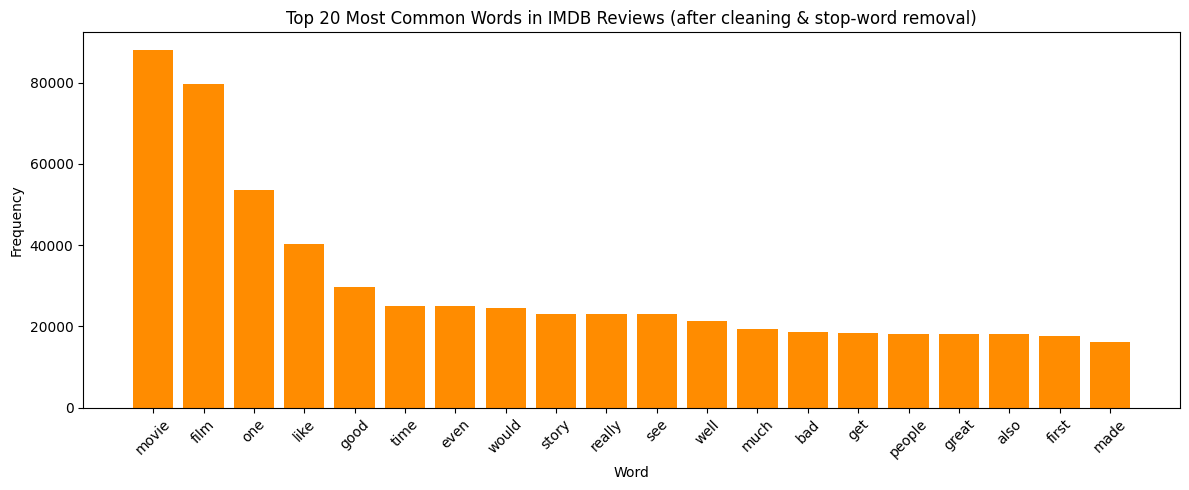

In [14]:
all_words = [w for tokens in df_imdb['tokens'] for w in tokens]
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

words, counts = zip(*top_20)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='darkorange')
plt.title('Top 20 Most Common Words in IMDB Reviews (after cleaning & stop-word removal)')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 5: Print the results

In [15]:
print("=== IMDB Reviews - Analysis Results ===")
print(f"Total number of reviews                         : {total_reviews}")
print(f"Average word count per review (after cleaning)   : {average_word_count:.2f}")
print(f"Reviews containing the word 'good' (positive)     : {positive_reviews}")
print(f"Reviews containing the word 'bad'  (negative)     : {negative_reviews}")
print()
print("Top 10 most common words:")
for i, (word, count) in enumerate(word_freq.most_common(10), start=1):
    print(f"{i:>2}. {word:<10} -> {count}")

=== IMDB Reviews - Analysis Results ===
Total number of reviews                         : 50000
Average word count per review (after cleaning)   : 118.15
Reviews containing the word 'good' (positive)     : 19004
Reviews containing the word 'bad'  (negative)     : 11788

Top 10 most common words:
 1. movie      -> 87972
 2. film       -> 79708
 3. one        -> 53603
 4. like       -> 40172
 5. good       -> 29753
 6. time       -> 25109
 7. even       -> 24872
 8. would      -> 24602
 9. story      -> 23121
10. really     -> 23095


---
# Task Solution (Lab3 - Part 2, Task#2): N-gram Generation from Poem Data

**Requirements covered in this section:**
1. Load the dataset from a CSV file.
2. Pre-process: tokenize, remove punctuation, lowercase, remove stop words.
3. Generate bi-grams from the pre-processed text and store them in a `bigrams` column.
4. Calculate the frequency of each unique bi-gram.
5. Display the top 10 most common bi-grams.

Dataset file (place next to this notebook): `Poem_classification_-_train_data.csv`

### Step 1: Load the data

In [16]:
from nltk.util import bigrams as nltk_bigrams

df_poems = pd.read_csv('Poem_classification_-_train_data.csv')
df_poems = df_poems.dropna(subset=['Poem']).reset_index(drop=True)

print("Rows loaded:", df_poems.shape[0])
df_poems.head()

Rows loaded: 837


,Genre,Poem
0,Music,In the thick brushthey spend the...
1,Music,Storms are generous. ...
2,Music,—After Ana Mendieta Did you carry around the ...
3,Music,for Aja Sherrard at 20The portent may itself ...
4,Music,"for Bob Marley, Bavaria, November 1980 Here i..."


### Step 2: Pre-process the text (tokenize, remove punctuation, lowercase, remove stop words)

In [17]:
def preprocess_poem(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)     # remove punctuation and numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

df_poems['tokens'] = df_poems['Poem'].apply(preprocess_poem)
df_poems[['Genre', 'tokens']].head(3)

,Genre,tokens
0,Music,"[thick, brushthey, spend, hottest, part, day, ..."
1,Music,"[storms, generous, something, easy, surrender,..."
2,Music,"[ana, mendieta, carry, around, matin, star, ho..."


### Step 3: Generate bi-grams and store them in a `bigrams` column

In [18]:
df_poems['bigrams'] = df_poems['tokens'].apply(lambda toks: list(nltk_bigrams(toks)))
df_poems[['Genre', 'bigrams']].head(3)

,Genre,bigrams
0,Music,"[(thick, brushthey), (brushthey, spend), (spen..."
1,Music,"[(storms, generous), (generous, something), (s..."
2,Music,"[(ana, mendieta), (mendieta, carry), (carry, a..."


### Step 4 & 5: Frequency of each unique bi-gram, and the top 10 most common

In [19]:
all_bigrams = [bg for bigram_list in df_poems['bigrams'] for bg in bigram_list]
bigram_freq = Counter(all_bigrams)

top_10_bigrams = bigram_freq.most_common(10)

print("Top 10 most common bi-grams in the poems dataset:\n")
for i, (bg, count) in enumerate(top_10_bigrams, start=1):
    print(f"{i:>2}. {bg[0]} {bg[1]:<12} -> {count}")

Top 10 most common bi-grams in the poems dataset:

 1. let us           -> 10
 2. ah yes          -> 8
 3. every day          -> 7
 4. let go           -> 6
 5. first time         -> 6
 6. come back         -> 6
 7. let say          -> 6
 8. parking lot          -> 6
 9. give us           -> 6
10. died august       -> 5


---
## What I Learned From This Lab

**N-grams and how they're built**
- A unigram/bigram/trigram is just a sliding window of 1/2/3 consecutive tokens over a sequence,
  built with `nltk.util.ngrams(tokens, n)` (or the shortcuts `nltk.bigrams()` / `nltk.trigrams()`).
- **Padding** (`<s>` / `</s>`) matters: without it, a model has no idea what word tends to *start*
  or *end* a sentence, since the first/last words never appear as the "next" token in any n-gram.

**Maximum Likelihood Estimation (MLE) language models**
- An MLE n-gram model is nothing more than counting: `P(word | context) = count(context, word) /
  count(context)`. `nltk.lm.MLE(n)` does exactly this once you feed it `padded_everygram_pipeline`.
- The model's **order** is a hard ceiling on what it can answer. A model built with `MLE(2)` only
  ever recorded contexts of length ≤ 1, so asking it for a 2-word context (a trigram-style query)
  doesn't raise an error — it silently returns `0`, which looks like a real answer but isn't. This
  is the reason the tweet task needed a second, order-3 model just for the trigram-level questions,
  even though the main model stayed a bigram.
- **Perplexity with zero smoothing is fragile.** Because probabilities are pure counts with nothing
  held back for unseen events, a single bigram in the test set that never appeared in training makes
  the whole sequence's probability (and therefore the perplexity) infinite. That's not a bug — it's
  exactly what unsmoothed MLE is supposed to do, and it's the textbook motivation for smoothing
  techniques (Laplace, Kneser-Ney, etc.) covered in Jurafsky & Martin Ch.3.

**Text pre-processing is task-specific, not one-size-fits-all**
- Tweets needed social-media-specific cleaning (mentions, hashtags, `RT`, URLs, emojis) that movie
  reviews and poems never see — but movie reviews had their own quirk instead (leftover HTML tags
  like `<br />` from how the dataset was scraped). Every text source carries the fingerprints of
  where it came from, so "clean the text" always means looking at the raw data first, not applying
  a fixed recipe blindly.
- Stop-word removal and lowercasing were shared across the IMDB and poem tasks, but the *question
  being asked* still shaped the pipeline: for IMDB, "positive"/"negative" were defined by simple
  keyword presence (`good`/`bad`) rather than the dataset's real sentiment label, which is a good
  reminder to read task instructions literally rather than substitute in a "smarter" method
  (like the actual `sentiment` column) that wasn't what was asked for.

**Practical takeaway**
- Across all three datasets, `collections.Counter` + `.most_common(n)` was the one recurring tool
  that turned raw token/n-gram lists into a ranked answer — the same simple idea (count things,
  then sort) is the backbone of both a "top 10 hashtags" question and a full n-gram language model.